# Path simulation of stochastic differential equations

<kbd>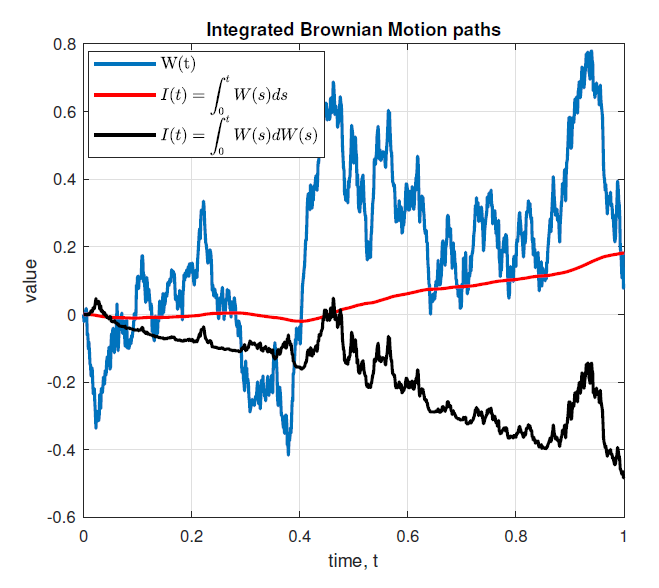 </kbd>

## Integration and path simulation of : $I(t) = \int g(s)dW(s)$

1. For a deterministic function $\Delta(t)$ let's determine the ito integral $I(t) = \int_0^T \Delta(s)dW(s)$

1. We can see
    * $t_0, t_1,..., t_{N-1}$ as trading dates
    * $\Delta(t_0),\Delta(t_1),...,\Delta(t_{N-1}), $ can be though as the number of shares held on each trading date
    * $W(t_i)$ as the price of 1 share of a stock at time $t_i$
    <br><br>
1. The gain from trading can be seen as  $$I(T) = \int_0^T \Delta(t)dW(t) \approx \sum_{k=0}^{N-1}  \Delta(t_k)  \left[ W(t_{k+1}) - W(t_{k}) \right] $$ <br>
<kbd>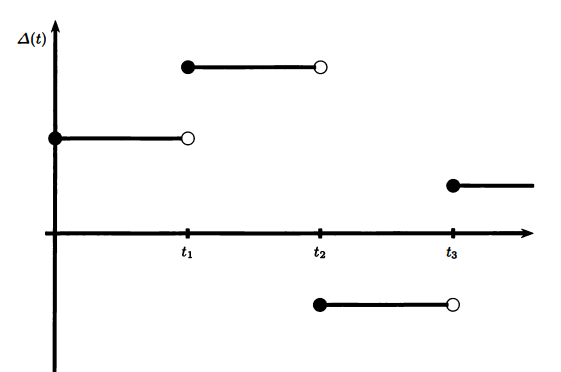</kbd>

1. Ito isometrie theorem :  $$\mathbb{E}\left[ I^2(T) \right] = \mathbb{E}\left[ \int_0^T \Delta^2(t) dt \right]$$



Below is a code example where we compute via monte carlo simulation the expectation and variance of $I(T)$. If $\Delta(t) = t^2$ and $T=1$ we have

$\mathbb{E}\left[ {\int_0^T t^2dW(t)} \right] = 0$ <br>
$\mathbb{Var}\left[ {\int_0^T t^2dW(t)} \right] = \mathbb{E}\left[ \int_0^T t^2 dt \right]^2 =\int_0^T t^4 dt  = 0.2$

Mean = -4.263256414560601e-18 and variance =0.19954975954492518


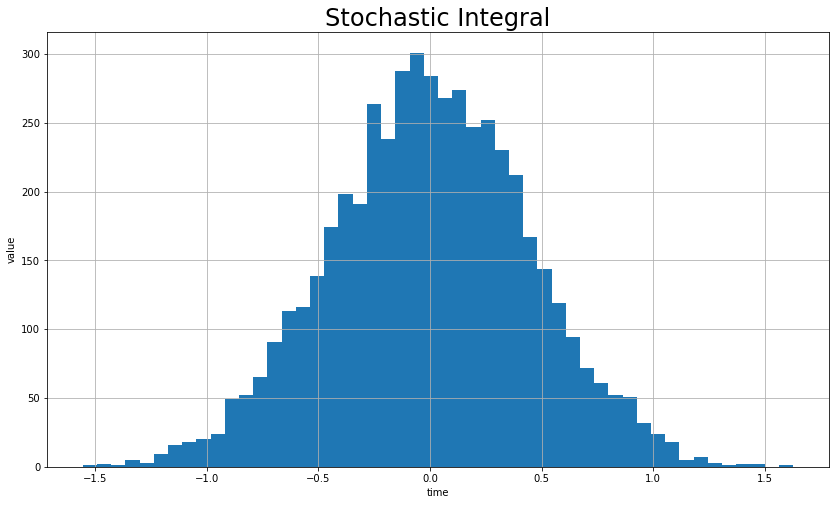

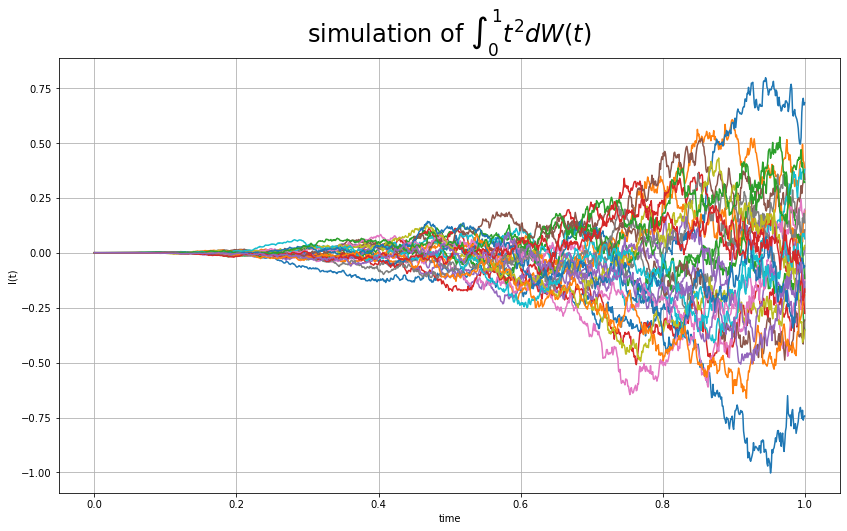

In [11]:
import numpy as np
import matplotlib.pyplot as plt


# M = number of paths
# N = number of steps
def ComputeIntegrals(M ,N,T, Δ):
    Z = np.random.normal(0.0,1.0,[M,N])
    W = np.zeros([M, N+1])
    I1 = np.zeros([M, N+1])
    t = np.zeros([N+1])
    
    dt = T / float(N)
    for i in range(0,N):
        # making sure that samples from normal have mean 0 and variance 1
        if M > 1: Z[:,i] = (Z[:,i] - np.mean(Z[:,i])) / np.std(Z[:,i])
        
        W[:,i+1] = W[:,i] + np.power(dt, 0.5)*Z[:,i]
        dW =  (W[:,i+1]-W[:,i]) 
        
        I1[:,i+1] = I1[:,i] + Δ(t[i]) * dW
        t[i+1] = t[i] + dt
        
    paths = {"time":t,"W":W,"I1":I1}
    return paths


M = 5_000
N = 1_000
T = 1
Δ = lambda t: t**2 

output = ComputeIntegrals(M,N,T , Δ)
timeGrid = output["time"]
I = output["I1"]

plt.figure(figsize=(14,8))
plt.figure(1)
plt.grid()
plt.hist(I[:,-1],50)
plt.xlabel("time")
plt.ylabel("value")
plt.title("Stochastic Integral",fontsize = 24)

EX = np.mean(I[:,-1])
Var = np.var(I[:,-1])
print('Mean = {0} and variance ={1}'.format(EX,Var))

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
plt.plot(timeGrid, np.transpose(I[0:25,:]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("I(t)");
plt.title(r"simulation of ${\int_0^1 t^2dW(t)} $", fontsize = 24);

## Integration and path simulation of : $I(t) = \int g(W_t)dt$

Below is a code example where we compute via monte carlo simulation the expectation and variance of $I(T)$. If $g(x) = x$ and $T=2$ we have

Mean = 2.6645352591003755e-19 and variance =0.32550532493366524


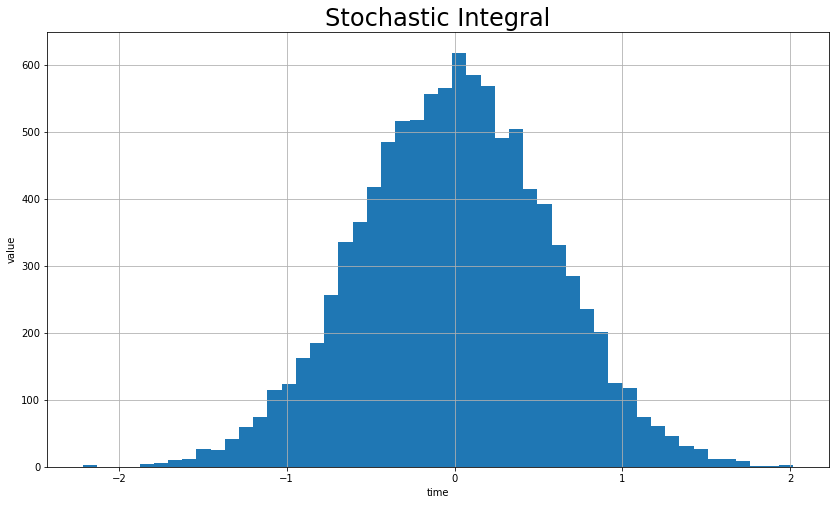

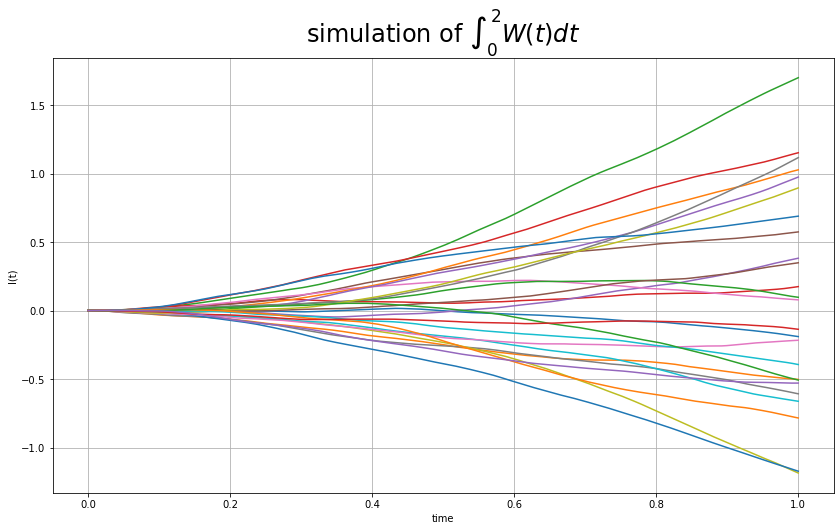

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def ComputeIntegrals(M,N,T, Δ):    
    Z = np.random.normal(0.0,1.0,[M,N])
    W = np.zeros([M, N+1])
    I1 = np.zeros([M, N+1])
    t = np.zeros([N+1])
    
    dt = T / float(N)
    for i in range(0,N):
        # making sure that samples from normal have mean 0 and variance 1
        if M > 1: Z[:,i] = (Z[:,i] - np.mean(Z[:,i])) / np.std(Z[:,i])
        W[:,i+1] = W[:,i] + np.power(dt, 0.5)*Z[:,i]
        
        I1[:,i+1] = I1[:,i] + Δ(W[:,i]) *dt
        t[i+1] = t[i] +dt
        
    paths = {"time":t,"W":W,"I1":I1}
    return paths


M = 10_000
N = 1_000
T = 1
Δ = lambda t: t


output = ComputeIntegrals(M,N,T , Δ)
timeGrid = output["time"]
I = output["I1"]

plt.figure(figsize=(14,8))
plt.figure(1)
plt.grid()
plt.hist(I[:,-1],50)
plt.xlabel("time")
plt.ylabel("value")
plt.title("Stochastic Integral",fontsize = 24)

EX = np.mean(I[:,-1])
Var = np.var(I[:,-1])
print('Mean = {0} and variance ={1}'.format(EX,Var))

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
plt.plot(timeGrid, np.transpose(I[0:25,:]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("I(t)");
plt.title(r"simulation of ${\int_0^2 W(t)dt} $", fontsize = 24);

## Integration and path simulation of : $I(t) = \int g(W_s)dW(s)$

Below is a code example where we compute via monte carlo simulation the expectation and variance of $I(T)$. If $g(x) = x$ and $T=2$ we have

$\mathbb{E}\left[ {\int_0^T W(t) dW(t)} \right] = 0$ <br>
$\mathbb{Var}\left[ {\int_0^T W(t)dW(t)} \right] = 2$

Mean = 0.007505160608369906 and variance =2.074612848259542


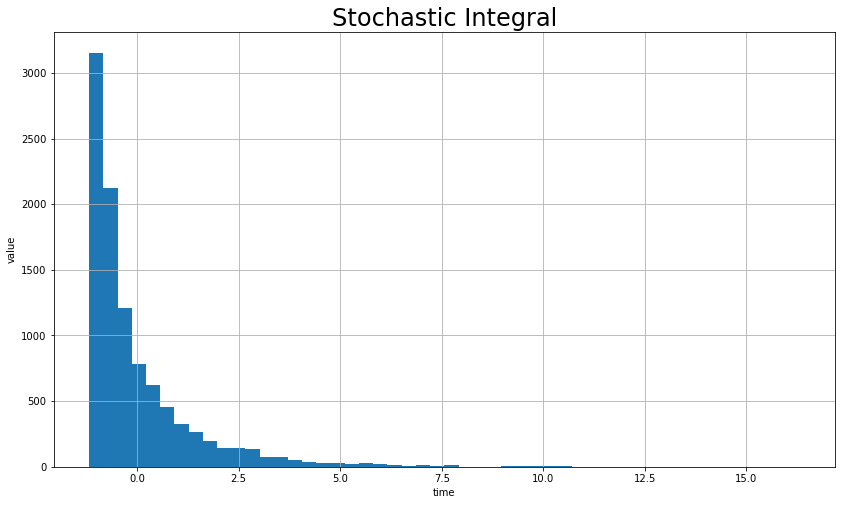

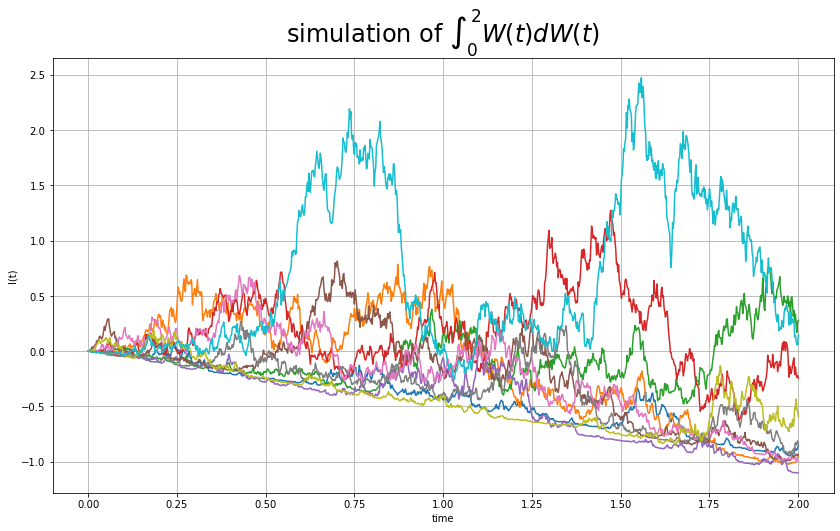

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def ComputeIntegrals(M,N,T, Δ):    
    Z = np.random.normal(0.0,1.0,[M,N])
    W = np.zeros([M, N+1])
    I1 = np.zeros([M, N+1])
    t = np.zeros([N+1])
    
    dt = T / float(N)
    for i in range(0,N):
        # making sure that samples from normal have mean 0 and variance 1
        if M > 1: Z[:,i] = (Z[:,i] - np.mean(Z[:,i])) / np.std(Z[:,i])
        W[:,i+1] = W[:,i] + np.power(dt, 0.5)*Z[:,i]
        dW = (W[:,i+1]-W[:,i])
        
        I1[:,i+1] = I1[:,i] + Δ(W[:,i]) * dW
        t[i+1] = t[i] +dt
        
    paths = {"time":t,"W":W,"I1":I1}
    return paths


NoOfPaths = 10_000
NoOfSteps = 1_000
T = 2
Δ = lambda t: t


output = ComputeIntegrals(M,N,T , Δ)
timeGrid = output["time"]
I = output["I1"]

plt.figure(figsize=(14,8))
plt.figure(1)
plt.grid()
plt.hist(I[:,-1],50)
plt.xlabel("time")
plt.ylabel("value")
plt.title("Stochastic Integral",fontsize = 24)

EX = np.mean(I[:,-1])
Var = np.var(I[:,-1])
print('Mean = {0} and variance ={1}'.format(EX,Var))

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
plt.plot(timeGrid, np.transpose(I[0:10,:]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("I(t)");
plt.title(r"simulation of ${\int_0^2 W(t)dW(t)} $", fontsize = 24);

## Integration and path simulation of : $I(t) = \int dW(s) dW(s)$

show that $dW*dW = dt$

Mean = 1.0 and variance =0.002014062525654763


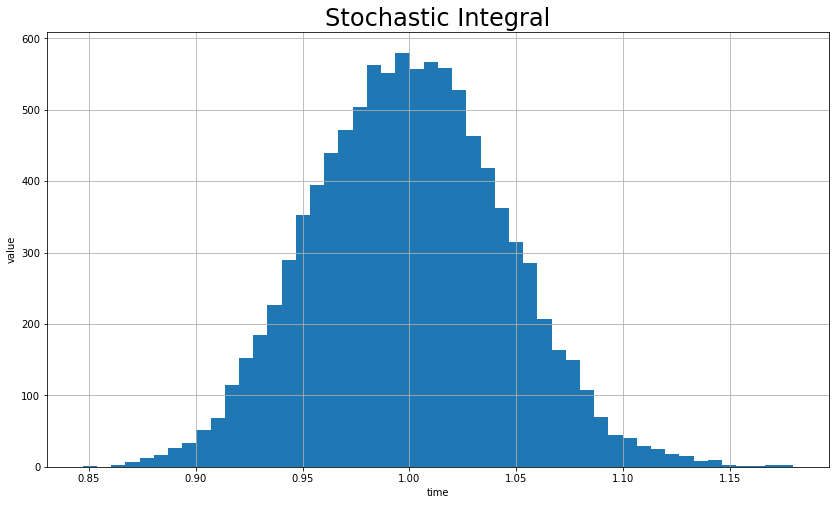

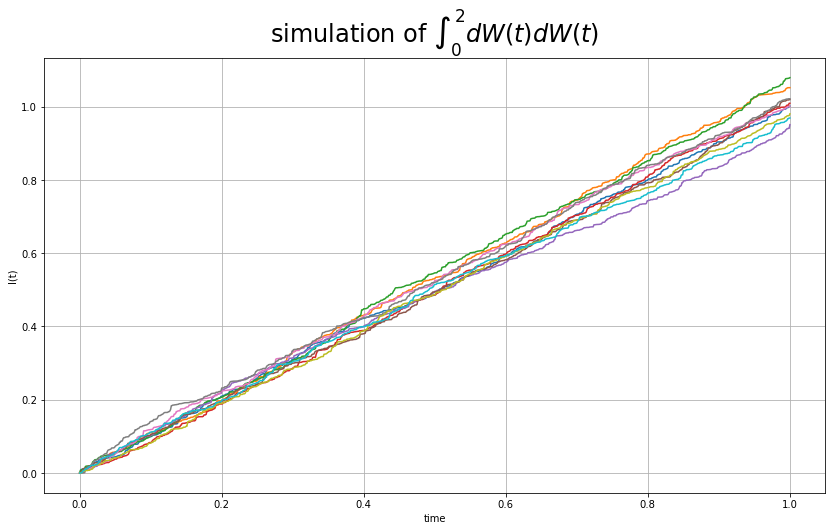

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def ComputeIntegrals(M,N,T):    
    Z = np.random.normal(0.0,1.0,[M,N])
    W = np.zeros([M, N+1])
    I1 = np.zeros([M, N+1])
    t = np.zeros([N+1])
    
    dt = T / float(N)
    for i in range(0,N):
        # making sure that samples from normal have mean 0 and variance 1
        if M > 1: Z[:,i] = (Z[:,i] - np.mean(Z[:,i])) / np.std(Z[:,i])
        W[:,i+1] = W[:,i] + np.power(dt, 0.5)*Z[:,i]
        dW = (W[:,i+1]-W[:,i])
        
        I1[:,i+1] = I1[:,i] +  dW * dW
        t[i+1] = t[i] +dt
        
    paths = {"time":t,"W":W,"I1":I1}
    return paths


NoOfPaths = 100_000
NoOfSteps = 1_000
T = 1


output = ComputeIntegrals(M,N,T )
timeGrid = output["time"]
I = output["I1"]

plt.figure(figsize=(14,8))
plt.figure(1)
plt.grid()
plt.hist(I[:,-1],50)
plt.xlabel("time")
plt.ylabel("value")
plt.title("Stochastic Integral",fontsize = 24)

EX = np.mean(I[:,-1])
Var = np.var(I[:,-1])
print('Mean = {0} and variance ={1}'.format(EX,Var))

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
plt.plot(timeGrid, np.transpose(I[0:10,:]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("I(t)");
plt.title(r"simulation of ${\int_0^2 dW(t)dW(t)} $", fontsize = 24);

## Expectation and Variance of $ \left( W_{t_{i+1}} -  W_{t_{i}} \right)^2$

1. From ito table we know that $dW_t^2 = dt$ below we perform a numerical experiment to see this

1. The numerical experiment shows that :
    * The Variance of $ \left( W_{t_{i+1}} -  W_{t_{i}} \right)^2$ tends to zero very quickly
    * And the  expected value of $ \left( W_{t_{i+1}} -  W_{t_{i}} \right)^2$ is dt

Text(0.5, 1.0, 'Plot dt vs E[dWt^2]')

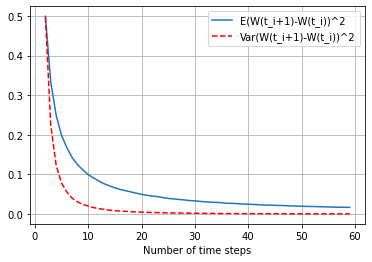

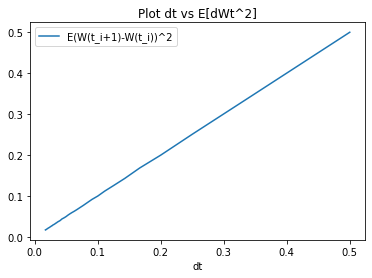

In [28]:
from numpy.random import lognormal, uniform, normal
from numpy import exp, linspace ,log, max, mean ,  sqrt, arange
M = 50000  # number of path
N = 60  # max number of time intervals
T=1.0 # time horizon

variance = []
mean = []

for n in range(2,N,1):
    dt = T/n
    t1 = 1.0*dt;
    t2 = 2.0*dt;
    W_t1 =  normal(0,1,[M,1]) * sqrt(t1)
    W_t2 = W_t1 + normal(0.0,1.0,[M,1])* sqrt(dt)
    X = (W_t2-W_t1)**2
    mean.append(np.mean(X))
    variance.append(np.var(X))

plt.figure(1)
plt.plot(range(2,N,1), mean)
plt.plot(range(2,N,1), variance,'--r')
plt.grid()
plt.legend(['E(W(t_i+1)-W(t_i))^2','Var(W(t_i+1)-W(t_i))^2'])
plt.xlabel('Number of time steps');
    

plt.figure(2)
plt.plot(1/ arange(2,N,1), mean)
plt.legend(['E(W(t_i+1)-W(t_i))^2'])
plt.xlabel('dt');
plt.title('Plot dt vs E[dWt^2]')